In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file = "/content/drive/MyDrive/plantVillageDataset.zip"
extract_path = "/content/plantVillageDataset"


# Unzip
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [ ]:
DATASET_PATH = "/content/plantVillageDataset/PlantVillage"

#  Filter only Tomato folders
all_folders = os.listdir(DATASET_PATH)
tomato_folders = [f for f in all_folders if f.lower().startswith("tomato")]

print(f"Total folders in dataset : {len(all_folders)}")
print(f"Tomato folders found     : {len(tomato_folders)}")
print("\n Tomato Classes:")

for i, folder in enumerate(sorted(tomato_folders)):
    count = len(os.listdir(os.path.join(DATASET_PATH, folder)))
    print(f"  {i+1:>2}. {folder:<50} ----- {count} images")

Total folders in dataset : 15
Tomato folders found     : 10

 Tomato Classes:
   1. Tomato_Bacterial_spot                              ----- 2127 images
   2. Tomato_Early_blight                                ----- 1000 images
   3. Tomato_Late_blight                                 ----- 1909 images
   4. Tomato_Leaf_Mold                                   ----- 952 images
   5. Tomato_Septoria_leaf_spot                          ----- 1771 images
   6. Tomato_Spider_mites_Two_spotted_spider_mite        ----- 1676 images
   7. Tomato__Target_Spot                                ----- 1404 images
   8. Tomato__Tomato_YellowLeaf__Curl_Virus              ----- 3209 images
   9. Tomato__Tomato_mosaic_virus                        ----- 373 images
  10. Tomato_healthy                                     ----- 1591 images


In [ ]:
TOMATO_CLASSES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy"
]

In [ ]:
import random
import shutil

OUTPUT_PATH = "data_split"
TRAIN_RATIO, VAL_RATIO = 0.7, 0.15

for cls in TOMATO_CLASSES:
    path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(path)
    random.shuffle(images)

    train_end = int(len(images)*TRAIN_RATIO)
    val_end = int(len(images)*(TRAIN_RATIO+VAL_RATIO))

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in splits.items():
        split_dir = os.path.join(OUTPUT_PATH, split, cls)
        os.makedirs(split_dir, exist_ok=True)

        for img in imgs:
            shutil.copyfile(
                os.path.join(path, img),
                os.path.join(split_dir, img)
            )

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
TRAIN_PATH = "data_split/train"
VAL_PATH   = "data_split/val"
TEST_PATH  = "data_split/test"

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 11203 images belonging to 10 classes.
Found 2402 images belonging to 10 classes.
Found 2406 images belonging to 10 classes.


In [ ]:
from matplotlib import pyplot as plt

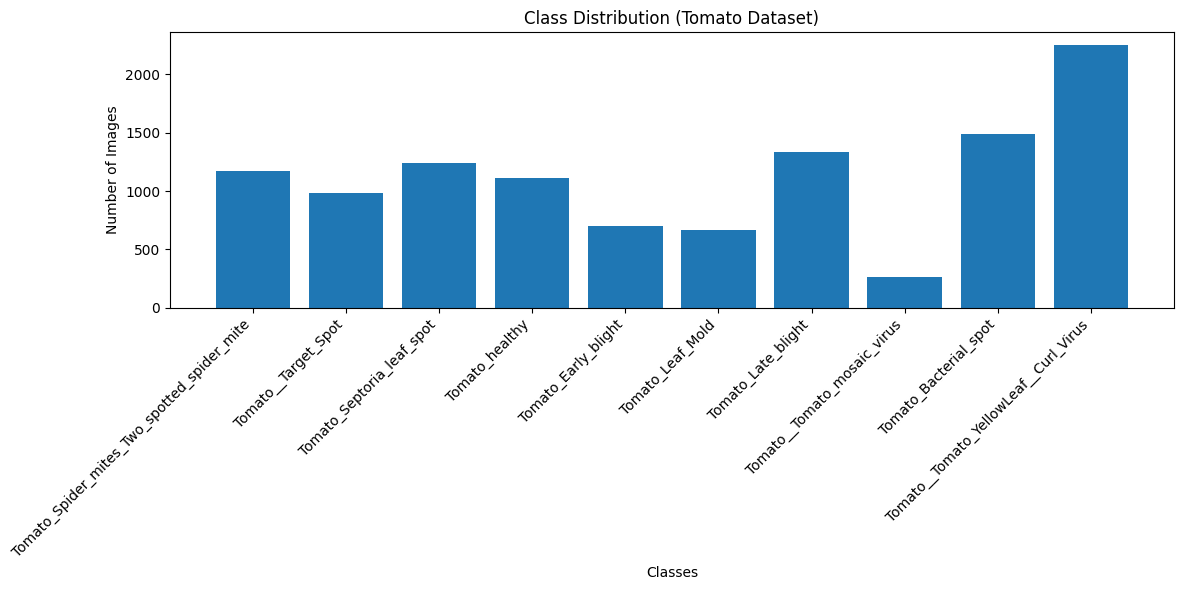

In [ ]:

class_counts = {}
for cls in os.listdir("data_split/train"):
    class_counts[cls] = len(os.listdir(os.path.join("data_split/train", cls)))

# Plot
plt.figure(figsize=(12,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Tomato Dataset)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

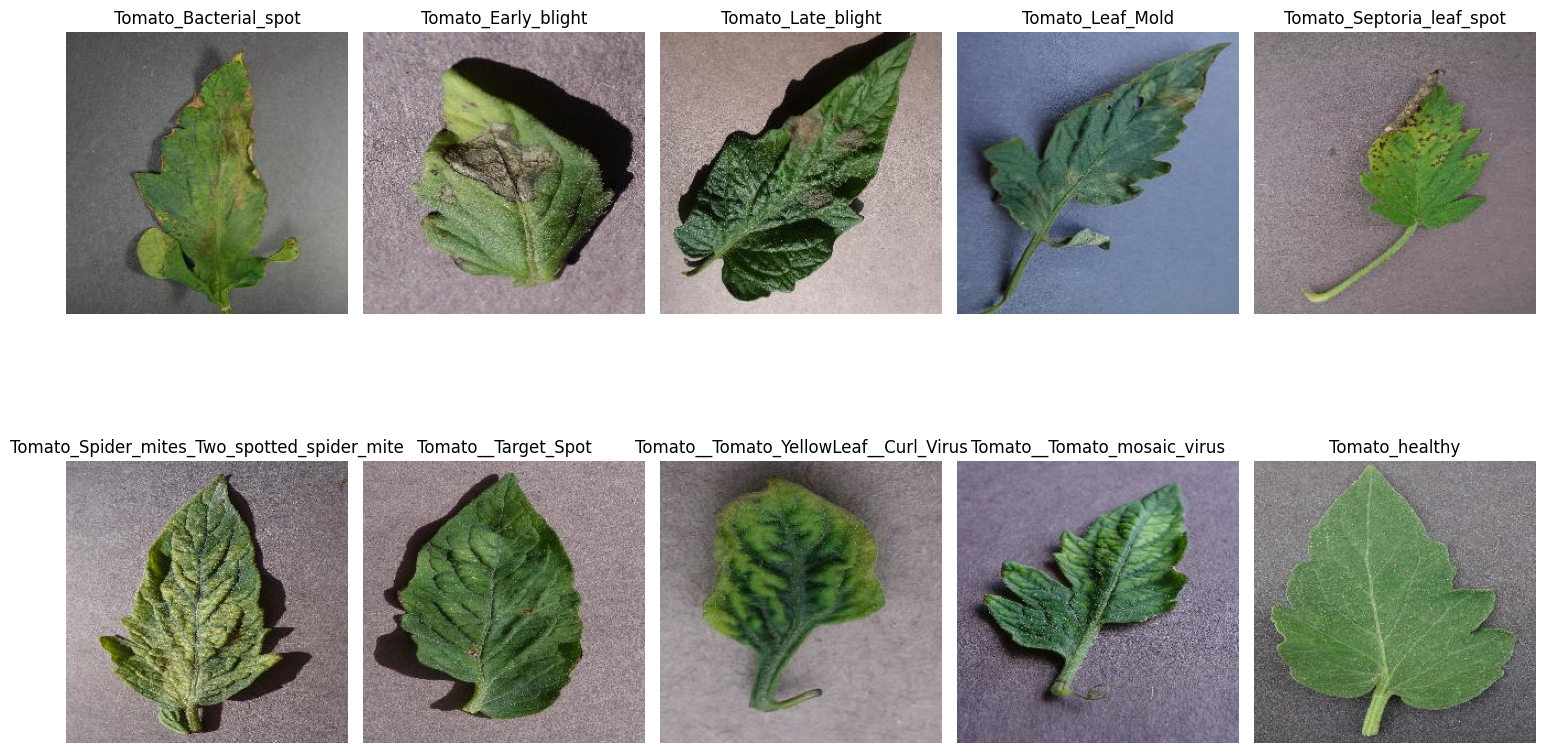

In [ ]:
import random
import cv2
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i, cls in enumerate(TOMATO_CLASSES[:10]):
    img_path = os.path.join("/content/data_split/train", cls)
    img_file = random.choice(os.listdir(img_path))

    img = cv2.imread(os.path.join(img_path, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))

In [ ]:
print(class_weights)

{0: np.float64(0.7528897849462366), 1: np.float64(1.6004285714285715), 2: np.float64(0.8385479041916167), 3: np.float64(1.682132132132132), 4: np.float64(0.9041969330104923), 5: np.float64(0.9550724637681159), 6: np.float64(1.1408350305498982), 7: np.float64(0.49902004454342985), 8: np.float64(4.292337164750958), 9: np.float64(1.0065588499550764)}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
num_classes = 10

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3),
    ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)
]

In [ ]:
print(train_gen.class_indices)

{'Tomato_Bacterial_spot': 0, 'Tomato_Early_blight': 1, 'Tomato_Late_blight': 2, 'Tomato_Leaf_Mold': 3, 'Tomato_Septoria_leaf_spot': 4, 'Tomato_Spider_mites_Two_spotted_spider_mite': 5, 'Tomato__Target_Spot': 6, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 7, 'Tomato__Tomato_mosaic_virus': 8, 'Tomato_healthy': 9}


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 222s 542ms/step - accuracy: 0.7125 - loss: 0.9555 - val_accuracy: 0.8068 - val_loss: 0.5229 - learning_rate: 0.0010
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 438ms/step - accuracy: 0.8217 - loss: 0.5777 - val_accuracy: 0.8722 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 165s 471ms/step - accuracy: 0.8498 - loss: 0.4760 - val_accuracy: 0.8751 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 152s 433ms/step - accuracy: 0.8649 - loss: 0.4256 - val_accuracy: 0.8893 - val_loss: 0.3116 - learning_rate: 0.0010
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 152s 432ms/step - accuracy: 0.8776 - loss: 0.3820 - val_accuracy: 0.8830 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 150s 428ms/step - accuracy: 0.8821 - loss: 0.3669 - val_accuracy: 0.8801 - val_loss: 0.3612 - learning_rate: 0.0010
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 425ms/step - accura

In [ ]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [ ]:
finetuning_callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3),
    ModelCheckpoint("best_finetuned_model.keras", monitor="val_accuracy", save_best_only=True)
]

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=finetuning_callbacks,
    verbose=1
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 155s 440ms/step - accuracy: 0.9177 - loss: 0.2574 - val_accuracy: 0.9388 - val_loss: 0.1894 - learning_rate: 1.0000e-05
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 152s 433ms/step - accuracy: 0.9200 - loss: 0.2316 - val_accuracy: 0.9417 - val_loss: 0.1824 - learning_rate: 1.0000e-05
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 152s 434ms/step - accuracy: 0.9289 - loss: 0.2134 - val_accuracy: 0.9425 - val_loss: 0.1779 - learning_rate: 1.0000e-05
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 440ms/step - accuracy: 0.9240 - loss: 0.2184 - val_accuracy: 0.9459 - val_loss: 0.1697 - learning_rate: 1.0000e-05
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 153s 437ms/step - accuracy: 0.9302 - loss: 0.2149 - val_accuracy: 0.9434 - val_loss: 0.1762 - learning_rate: 1.0000e-05
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 437ms/step - accuracy: 0.9348 - loss: 0.2039 - val_accuracy: 0.9475 - val_loss: 0.1631 - learning_rate: 1.0000e-05
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9593 - loss: 0.1352
Test Accuracy: 0.9592685103416443


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

print(classification_report(test_gen.classes, y_pred))

76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       320
           1       0.97      0.91      0.94       150
           2       0.96      0.99      0.97       287
           3       0.99      0.98      0.98       143
           4       0.92      0.97      0.94       266
           5       0.95      0.94      0.94       252
           6       0.87      0.95      0.91       211
           7       1.00      0.97      0.98       482
           8       1.00      0.98      0.99        56
           9       0.97      1.00      0.98       239

    accuracy                           0.96      2406
   macro avg       0.96      0.96      0.96      2406
weighted avg       0.96      0.96      0.96      2406



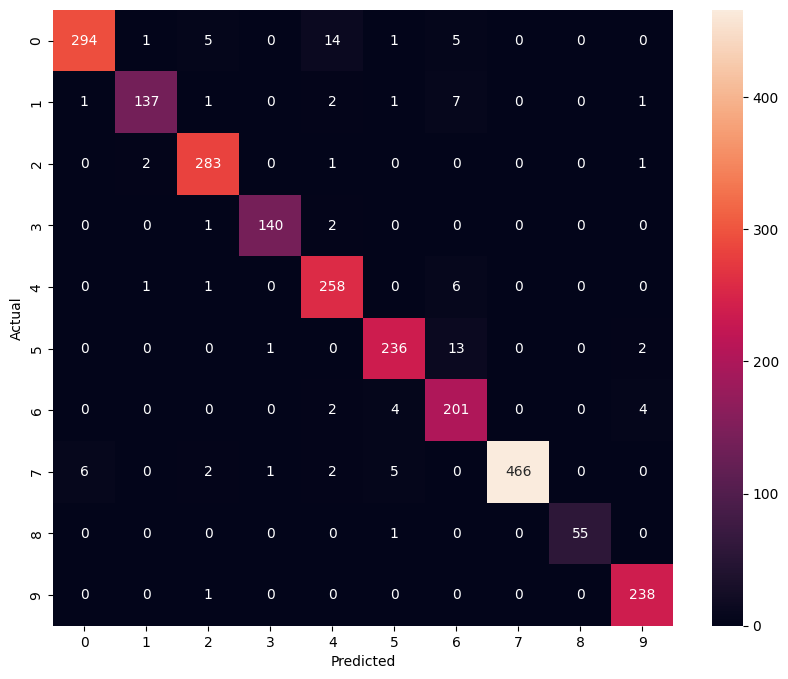

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import os, shutil, random

SRC_PATH = "data_split"
HALF_PATH = "data_half"

# clean previous
if os.path.exists(HALF_PATH):
    shutil.rmtree(HALF_PATH)

splits = ["train", "val", "test"]

for split in splits:
    for cls in os.listdir(os.path.join(SRC_PATH, split)):

        src_dir = os.path.join(SRC_PATH, split, cls)
        dst_dir = os.path.join(HALF_PATH, split, cls)
        os.makedirs(dst_dir, exist_ok=True)

        images = os.listdir(src_dir)
        random.shuffle(images)

        half = images[:len(images)//2]  # take 50%

        for img in half:
            shutil.copyfile(
                os.path.join(src_dir, img),
                os.path.join(dst_dir, img)
            )

In [ ]:
def count_data(base):
    total = 0
    for split in ["train", "val", "test"]:
        for cls in os.listdir(os.path.join(base, split)):
            total += len(os.listdir(os.path.join(base, split, cls)))
    return total

print("Original:", count_data("data_split"))
print("Half:", count_data("data_half"))

Original: 16012
Half: 7999


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_half = train_datagen.flow_from_directory(
    "data_half/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='sparse'
)

val_gen_half = val_datagen.flow_from_directory(
    "data_half/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='sparse'
)

test_gen_half = val_datagen.flow_from_directory(
    "data_half/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 5600 images belonging to 10 classes.
Found 1198 images belonging to 10 classes.
Found 1201 images belonging to 10 classes.


In [ ]:
history_half_1 = model.fit(
    train_gen_half,
    validation_data=val_gen_half,
    epochs=15,
    callbacks = finetuning_callbacks,
    verbose=1
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 102s 579ms/step - accuracy: 0.9554 - loss: 0.1271 - val_accuracy: 0.9599 - val_loss: 0.1170 - learning_rate: 1.0000e-05
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 429ms/step - accuracy: 0.9568 - loss: 0.1254 - val_accuracy: 0.9633 - val_loss: 0.1090 - learning_rate: 1.0000e-05
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 432ms/step - accuracy: 0.9598 - loss: 0.1164 - val_accuracy: 0.9649 - val_loss: 0.1074 - learning_rate: 1.0000e-05
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 427ms/step - accuracy: 0.9571 - loss: 0.1143 - val_accuracy: 0.9658 - val_loss: 0.1051 - learning_rate: 1.0000e-05
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 426ms/step - accuracy: 0.9607 - loss: 0.1140 - val_accuracy: 0.9658 - val_loss: 0.1025 - learning_rate: 1.0000e-05
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 428ms/step - accuracy: 0.9639 - loss: 0.1101 - val_accuracy: 0.9674 - val_loss: 0.0974 - learning_rate: 1.0000e-05
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 4

In [ ]:
import tensorflow as tf

for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_half_2 = model.fit(
    train_gen_half,
    validation_data=val_gen_half,
    epochs=15,
    callbacks = finetuning_callbacks,
    verbose=1
)


Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 505ms/step - accuracy: 0.9679 - loss: 0.0885 - val_accuracy: 0.9725 - val_loss: 0.0862 - learning_rate: 1.0000e-05
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 431ms/step - accuracy: 0.9743 - loss: 0.0822 - val_accuracy: 0.9699 - val_loss: 0.0826 - learning_rate: 1.0000e-05
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 430ms/step - accuracy: 0.9684 - loss: 0.0850 - val_accuracy: 0.9716 - val_loss: 0.0833 - learning_rate: 1.0000e-05
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 437ms/step - accuracy: 0.9716 - loss: 0.0826 - val_accuracy: 0.9716 - val_loss: 0.0800 - learning_rate: 1.0000e-05
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 434ms/step - accuracy: 0.9732 - loss: 0.0768 - val_accuracy: 0.9708 - val_loss: 0.0824 - learning_rate: 1.0000e-05
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 436ms/step - accuracy: 0.9761 - loss: 0.0724 - val_accuracy: 0.9725 - val_loss: 0.0805 - learning_rate: 1.0000e-05
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 4

In [ ]:
test_loss, test_acc = model.evaluate(test_gen_half)
print("Half Data Test Accuracy:", test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 380ms/step - accuracy: 0.9792 - loss: 0.0687
Half Data Test Accuracy: 0.9791840314865112
